# EDA del dataset `clientes.csv`

## Caso practico: Union Central Voz



## Objetivos del EDA

En este analisis vamos a trabajar con cuatro metas claras:

1. Entender la estructura del dataset y el significado operativo de sus variables.
2. Detectar problemas de calidad de datos antes de plantear cualquier modelado.
3. Caracterizar el perfil de clientes desde una perspectiva descriptiva.
4. Formular hipotesis de negocio plausibles y contrastarlas con evidencia estadistica simple.

Una idea importante: en un proyecto real, un buen EDA no es una coleccion de graficos. Es una secuencia de preguntas bien planteadas, con decisiones justificadas.


## Hipotesis iniciales

Antes de mirar los datos conviene explicitar algunas hipotesis razonables. Eso nos ayuda a no analizar de forma caotica.

- Hipotesis H1:
Los clientes con `tipo_plan = Premium` deberian tener, en promedio, mayor `ingreso_estimado` que los clientes de planes mas basicos.

- Hipotesis H2:
La variable `descuento_activo` no deberia distribuirse de forma uniforme entre planes; es razonable esperar diferencias por estrategia comercial.

- Hipotesis H3:
El numero de lineas (`num_lineas`) podria variar segun `estado_civil`, porque los hogares o unidades familiares suelen concentrar mas servicios.

Estas hipotesis no son conclusiones. Son puntos de partida que guiaremos con analisis descriptivo y, cuando tenga sentido, con contrastes estadisticos sencillos.


In [17]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import sys

# Añadimos la raíz del proyecto al path para poder importar src/
sys.path.append(str(Path('..').resolve()))

# load_clientes() solo parsea tipos básicos (fechas, enteros)
# NO limpia datos — eso es responsabilidad de clean.py
from src.load  import load_clientes
from src.utils import missing_summary, iqr_outlier_mask, cramers_v, resumen_categorica

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías cargadas')


Librerías cargadas


## 1. Carga del dataset

Trabajamos con el fichero compartido para alumnado. El primer paso es cargarlo y revisar rapidamente su forma general.


In [18]:
# Cargamos el CSV crudo — sin limpieza de negocio
# El EDA trabaja sobre los datos reales para DESCUBRIR los problemas,
# no sobre datos ya limpios. Los hallazgos aquí son los que justifican clean.py.
df = load_clientes()

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()


[load] clientes:    10,150 filas x 14 columnas
Filas: 10,150
Columnas: 14


,cliente_id,zona_id,region,tipo_zona,poblacion_zona,edad,sexo,estado_civil,num_lineas,tipo_plan,tipo_dispositivo,ingreso_estimado,antiguedad_meses,descuento_activo
0,C000001,Z26,Oeste,urbana_premium,107159,18.00,M,Soltero/a,2,Prepago,Gama alta,"4,335.00",72.00,0
1,C000002,Z15,Oeste,suburbana,62939,54.00,M,Casado/a,2,Premium,Gama media,"4,609.00",35.00,1
2,C000003,Z27,Norte,suburbana,42704,54.00,M,Casado/a,3,Prepago,Gama baja,"1,836.00",11.00,0
3,C000004,Z22,Este,suburbana,53534,34.00,M,Soltero/a,1,Prepago,Gama media,"2,318.00",13.00,0
4,C000005,Z04,Centro,suburbana,55457,46.00,F,Soltero/a,2,Contrato,Gama media,"2,184.00",21.00,0


## 2. Estructura, tipos y primera lectura

En esta fase respondemos preguntas basicas:

- Que representa una fila.
- Que variables parecen identificadores.
- Que variables son numericas y cuales categoricas.
- Si los tipos inferidos por pandas tienen sentido.

La inspeccion temprana evita errores posteriores. Por ejemplo, una variable numerica leida como texto puede distorsionar toda la exploracion.


In [19]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10150 entries, 0 to 10149
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cliente_id        10150 non-null  object 
 1   zona_id           10150 non-null  object 
 2   region            10150 non-null  object 
 3   tipo_zona         10150 non-null  object 
 4   poblacion_zona    10150 non-null  int64  
 5   edad              9845 non-null   float64
 6   sexo              10105 non-null  object 
 7   estado_civil      10071 non-null  object 
 8   num_lineas        10150 non-null  int64  
 9   tipo_plan         10150 non-null  object 
 10  tipo_dispositivo  10150 non-null  object 
 11  ingreso_estimado  9846 non-null   float64
 12  antiguedad_meses  9845 non-null   float64
 13  descuento_activo  10150 non-null  int64  
dtypes: float64(3), int64(3), object(8)
memory usage: 1.1+ MB


In [20]:
display(df.describe(include='all').T)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cliente_id,10150,10000,C001047,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zona_id,10150,31,Z26,824,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,10150,5,Oeste,3064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tipo_zona,10150,3,urbana_premium,4548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
poblacion_zona,"10,150.00",NaN,NaN,NaN,"59,980.39","28,712.48","11,707.00","41,163.00","56,480.50","72,683.00","107,159.00"
edad,"9,845.00",NaN,NaN,NaN,39.32,11.97,18.00,31.00,39.00,47.00,80.00
sexo,10105,4,F,5125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
estado_civil,10071,4,Soltero/a,5584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_lineas,"10,150.00",NaN,NaN,NaN,2.31,1.02,1.00,2.00,2.00,3.00,5.00
tipo_plan,10150,3,Premium,5136,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Diagnostico de calidad de datos

Antes de estudiar perfiles de cliente, necesitamos comprobar si el dataset es analiticamente fiable.

Aqui revisaremos al menos cinco tipos de incidencias:

1. Valores ausentes.
2. Duplicados.
3. Categorias inesperadas.
4. Valores imposibles o incoherentes.
5. Posibles claves rotas o identificadores anómalos.

En un EDA profesional, esta seccion no es opcional. Si se omite, el resto del analisis pierde credibilidad.


In [21]:
missing = missing_summary(df)
display(missing)


,n_missing,pct_missing,dtype
edad,305,3.00,float64
antiguedad_meses,305,3.00,float64
ingreso_estimado,304,3.00,float64
estado_civil,79,0.78,object
sexo,45,0.44,object
cliente_id,0,0.00,object
zona_id,0,0.00,object
region,0,0.00,object
tipo_zona,0,0.00,object
poblacion_zona,0,0.00,int64


In [22]:
expected_sexo = {'M', 'F'}
expected_estado_civil = {'Soltero/a', 'Casado/a', 'Divorciado/a'}

quality_checks = {
    'duplicados_fila_completa': int(df.duplicated().sum()),
    'cliente_id_duplicado': int(df['cliente_id'].duplicated().sum()),
    'sexo_fuera_catalogo': int((~df['sexo'].isin(expected_sexo)).sum()),
    'estado_civil_fuera_catalogo': int((~df['estado_civil'].isin(expected_estado_civil)).sum()),
    'antiguedad_negativa': int((pd.to_numeric(df['antiguedad_meses'], errors='coerce') < 0).sum()),
    'edad_faltante': int(df['edad'].isna().sum()),
    'ingreso_faltante': int(df['ingreso_estimado'].isna().sum()),
    'zona_id_Z99': int((df['zona_id'] == 'Z99').sum())
}

pd.DataFrame.from_dict(quality_checks, orient='index', columns=['n_casos'])


,n_casos
duplicados_fila_completa,150
cliente_id_duplicado,150
sexo_fuera_catalogo,154
estado_civil_fuera_catalogo,153
antiguedad_negativa,145
edad_faltante,305
ingreso_faltante,304
zona_id_Z99,152


### Lectura docente de esta seccion

Si encontramos nulos en `edad`, `ingreso_estimado` o `antiguedad_meses`, no debemos imputar de forma impulsiva. Primero conviene preguntarse si el patron de ausencia parece aleatorio o si podria esconder un sesgo de captura.

Si aparecen categorias como `?`, `X`, `NA`, `n/a` o `desconocido`, el problema ya no es solo tecnico. Tambien afecta a la interpretacion del negocio y a la consistencia del catalogo.

La existencia de antiguedades negativas o zonas como `Z99` sugiere que el dataset puede incluir errores introducidos de forma deliberada para entrenamiento. Precisamente por eso, este EDA debe dejar clara la diferencia entre describir el dato disponible y aceptar que ese dato es correcto.


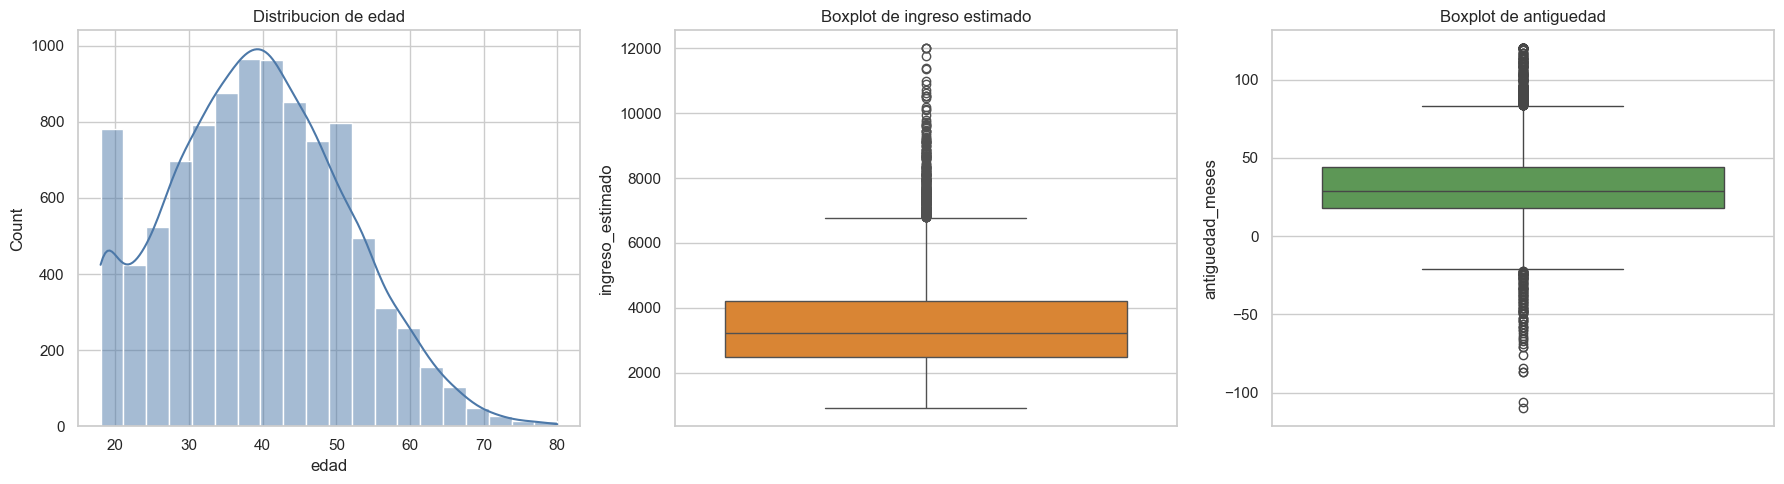

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['edad'], bins=20, kde=True, ax=axes[0], color='#4C78A8')
axes[0].set_title('Distribucion de edad')

sns.boxplot(y=df['ingreso_estimado'], ax=axes[1], color='#F58518')
axes[1].set_title('Boxplot de ingreso estimado')

sns.boxplot(y=df['antiguedad_meses'], ax=axes[2], color='#54A24B')
axes[2].set_title('Boxplot de antiguedad')

plt.tight_layout()


## 4. Construccion de una base analitica minima

Para seguir con el EDA sin mezclar descripcion con errores evidentes, vamos a crear una version de trabajo `df_eda`.

No es una limpieza definitiva. Es una base minima para analizar patrones sin que valores claramente invalidos contaminen los resultados.

Criterios aplicados:

- Eliminamos duplicados exactos.
- Convertimos a numerico las variables continuas relevantes.
- Sustituimos categorias fuera de catalogo por `NaN`.
- Marcamos `antiguedad_meses < 0` como valor invalido.
- Conservamos el resto de observaciones para no hacer una poda excesiva.

Este paso es importante desde el punto de vista docente: un EDA riguroso debe dejar trazabilidad de cualquier decision de depuracion intermedia.


In [24]:
df_eda = df.drop_duplicates().copy()

numeric_cols = ['edad', 'poblacion_zona', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'descuento_activo']
for col in numeric_cols:
    df_eda[col] = pd.to_numeric(df_eda[col], errors='coerce')

df_eda.loc[~df_eda['sexo'].isin(expected_sexo), 'sexo'] = np.nan
df_eda.loc[~df_eda['estado_civil'].isin(expected_estado_civil), 'estado_civil'] = np.nan
df_eda.loc[df_eda['antiguedad_meses'] < 0, 'antiguedad_meses'] = np.nan

print(f'Filas originales: {len(df):,}')
print(f'Filas tras quitar duplicados exactos: {len(df_eda):,}')
print(f'Porcentaje retenido: {len(df_eda) / len(df) * 100:.2f}%')


Filas originales: 10,150
Filas tras quitar duplicados exactos: 10,000
Porcentaje retenido: 98.52%


## 5. Analisis univariante

El objetivo aqui es caracterizar la poblacion de clientes de forma ordenada.

Preguntas clave:

- Que perfil de edad predomina.
- Cuantas lineas suele tener un cliente.
- Como se distribuyen ingreso y antiguedad.
- Que planes, dispositivos y zonas son mas frecuentes.

Conviene separar claramente variables numericas y categoricas, porque la forma de leerlas y visualizarlas es distinta.


In [25]:
numerical_cols = ['edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'poblacion_zona']
display(df_eda[numerical_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
edad,"9,700.00",39.34,11.97,18.00,31.00,39.00,47.00,80.00
num_lineas,"10,000.00",2.31,1.02,1.00,2.00,2.00,3.00,5.00
ingreso_estimado,"9,700.00","3,476.79","1,411.89",900.00,"2,466.00","3,219.00","4,194.25","12,000.00"
antiguedad_meses,"9,555.00",33.56,20.98,1.00,18.00,29.00,45.00,120.00
poblacion_zona,"10,000.00","60,004.60","28,724.37","11,707.00","41,163.00","56,342.00","72,683.00","107,159.00"


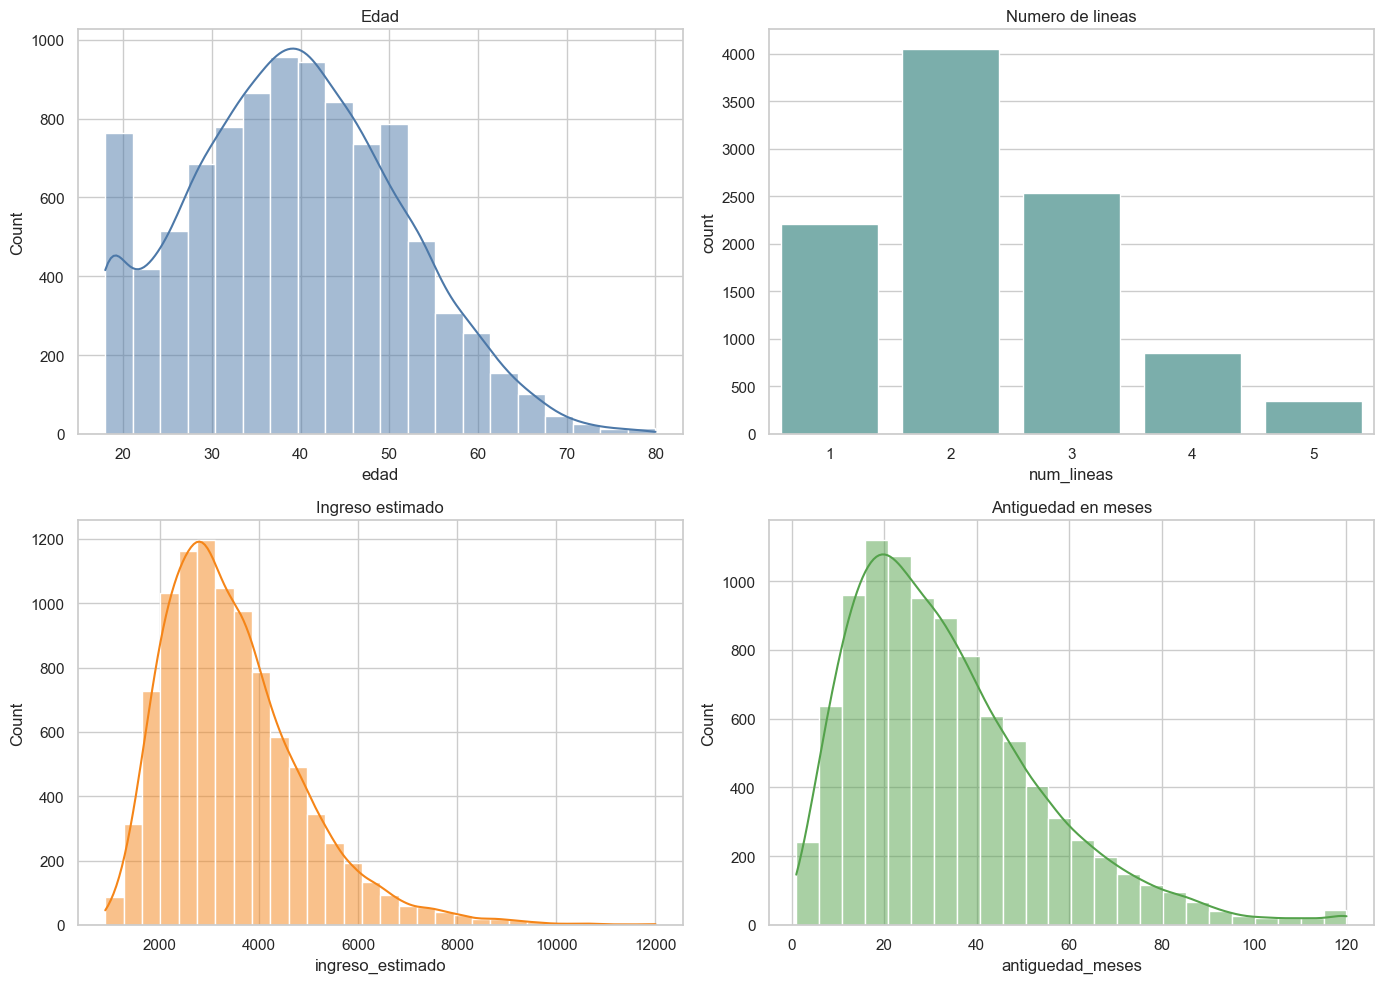

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(df_eda['edad'], bins=20, kde=True, ax=axes[0, 0], color='#4C78A8')
axes[0, 0].set_title('Edad')

sns.countplot(data=df_eda, x='num_lineas', ax=axes[0, 1], color='#72B7B2')
axes[0, 1].set_title('Numero de lineas')

sns.histplot(df_eda['ingreso_estimado'], bins=30, kde=True, ax=axes[1, 0], color='#F58518')
axes[1, 0].set_title('Ingreso estimado')

sns.histplot(df_eda['antiguedad_meses'], bins=24, kde=True, ax=axes[1, 1], color='#54A24B')
axes[1, 1].set_title('Antiguedad en meses')

plt.tight_layout()


In [27]:
categorical_cols = ['region', 'tipo_zona', 'sexo', 'estado_civil', 'tipo_plan', 'tipo_dispositivo', 'descuento_activo']

for col in categorical_cols:
    print(f'\n===== {col} =====')
    display(
        pd.DataFrame({
            'frecuencia': df_eda[col].value_counts(dropna=False),
            'porcentaje': df_eda[col].value_counts(normalize=True, dropna=False).mul(100).round(2)
        })
    )



===== region =====


,frecuencia,porcentaje
region,,
Oeste,3020,30.20
Este,2405,24.05
Sur,1852,18.52
Norte,1524,15.24
Centro,1199,11.99



===== tipo_zona =====


,frecuencia,porcentaje
tipo_zona,,
urbana_premium,4485,44.85
suburbana,4023,40.23
rural,1492,14.92



===== sexo =====


...

,frecuencia,porcentaje
tipo_plan,,
Premium,5062,50.62
Prepago,2680,26.80
Contrato,2258,22.58



===== tipo_dispositivo =====


,frecuencia,porcentaje
tipo_dispositivo,,
Gama media,6060,60.60
Gama alta,3076,30.76
Gama baja,864,8.64



===== descuento_activo =====


,frecuencia,porcentaje
descuento_activo,,
0,7450,74.50
1,2550,25.50


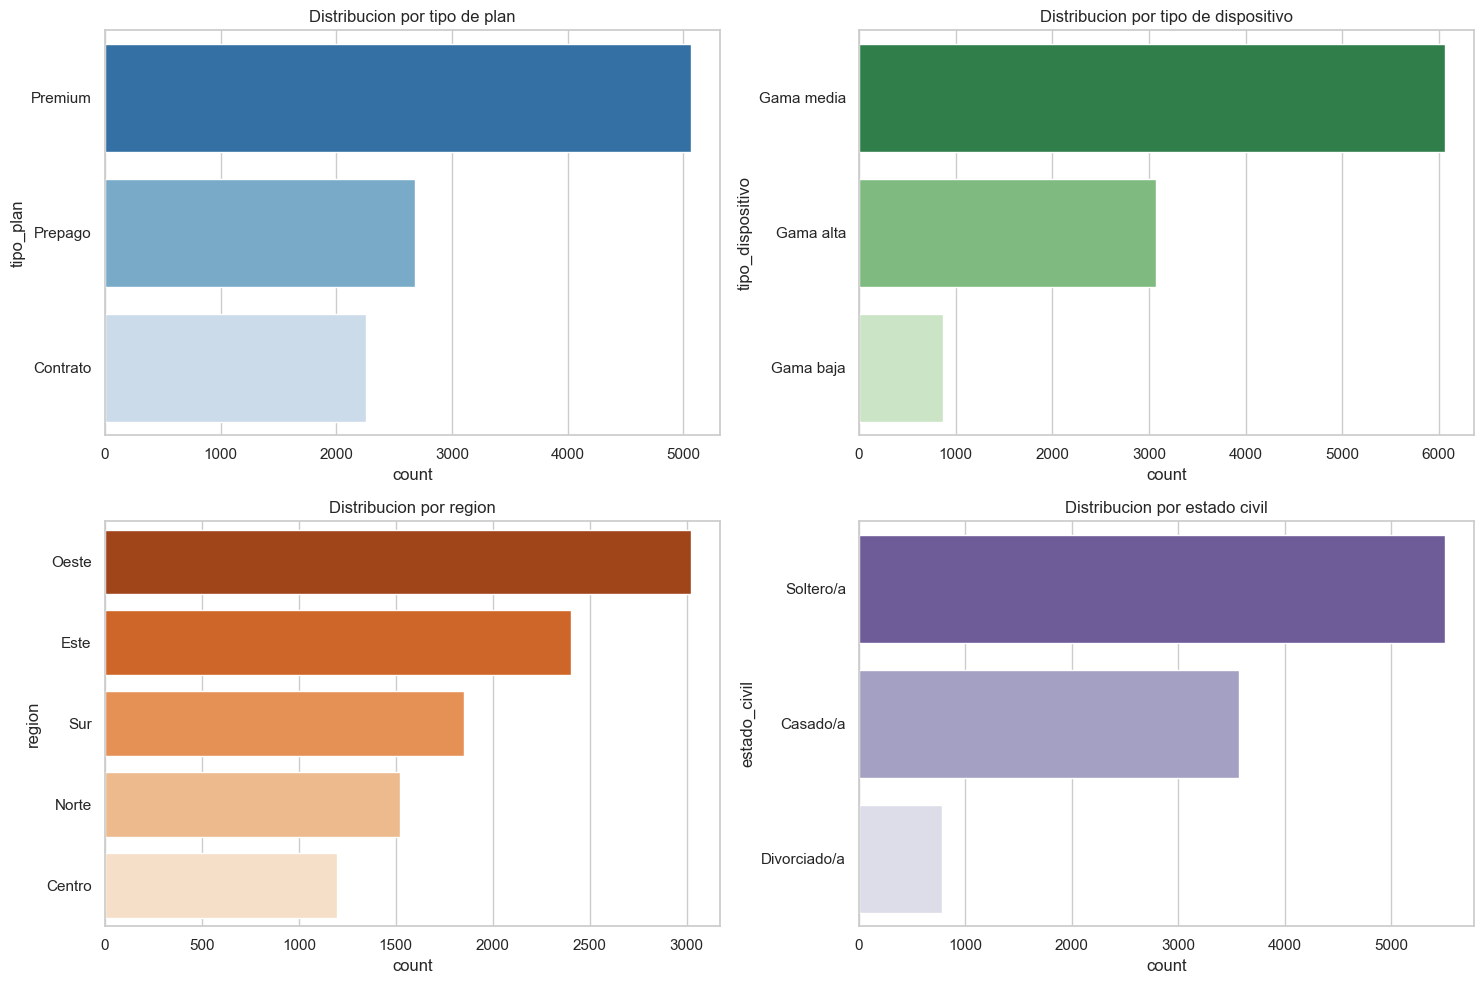

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df_eda, y='tipo_plan', order=df_eda['tipo_plan'].value_counts().index, ax=axes[0, 0], palette='Blues_r')
axes[0, 0].set_title('Distribucion por tipo de plan')

sns.countplot(data=df_eda, y='tipo_dispositivo', order=df_eda['tipo_dispositivo'].value_counts().index, ax=axes[0, 1], palette='Greens_r')
axes[0, 1].set_title('Distribucion por tipo de dispositivo')

sns.countplot(data=df_eda, y='region', order=df_eda['region'].value_counts().index, ax=axes[1, 0], palette='Oranges_r')
axes[1, 0].set_title('Distribucion por region')

sns.countplot(data=df_eda, y='estado_civil', order=df_eda['estado_civil'].value_counts().index, ax=axes[1, 1], palette='Purples_r')
axes[1, 1].set_title('Distribucion por estado civil')

plt.tight_layout()


## 6. Analisis bivariante y contrastes sencillos

Una vez entendidas las distribuciones marginales, pasamos a relaciones entre variables.

No todos los cruces requieren un test formal. Sin embargo, cuando planteamos hipotesis concretas, es util complementar los graficos con contrastes sencillos:

- Para comparar una variable numerica entre varios grupos: Kruskal-Wallis.
- Para estudiar asociacion entre dos categoricas: chi-cuadrado.

Elegimos Kruskal-Wallis en vez de ANOVA porque es mas robusto cuando no queremos asumir normalidad o igualdad de varianzas, algo razonable en un contexto exploratorio.


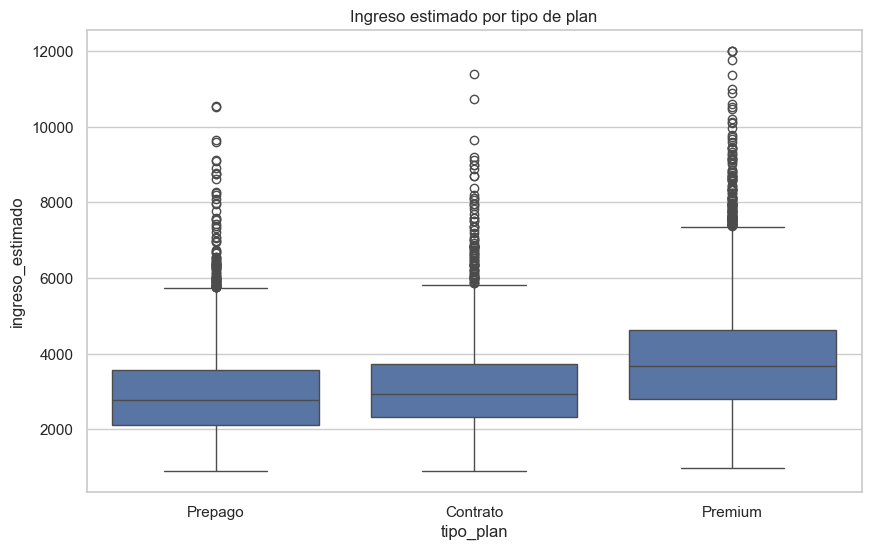

,count,median,mean
tipo_plan,,,
Prepago,2592,"2,765.50","2,994.32"
Contrato,2191,"2,935.00","3,188.15"
Premium,4917,"3,662.00","3,859.74"


Estadistico Kruskal-Wallis: 902.814
P-valor: 0.000000


In [29]:
df_h1 = df_eda.dropna(subset=['tipo_plan', 'ingreso_estimado']).copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_h1, x='tipo_plan', y='ingreso_estimado', order=['Prepago', 'Contrato', 'Premium'])
plt.title('Ingreso estimado por tipo de plan')
plt.show()

groups_h1 = [
    df_h1.loc[df_h1['tipo_plan'] == plan, 'ingreso_estimado']
    for plan in ['Prepago', 'Contrato', 'Premium']
]

kw_h1 = stats.kruskal(*groups_h1)
summary_h1 = df_h1.groupby('tipo_plan')['ingreso_estimado'].agg(['count', 'median', 'mean']).sort_values('median')

display(summary_h1)
print(f'Estadistico Kruskal-Wallis: {kw_h1.statistic:.3f}')
print(f'P-valor: {kw_h1.pvalue:.6f}')


### Interpretacion de H1

Si el p-valor es pequeno, rechazamos la hipotesis nula de igualdad de distribuciones y concluimos que el ingreso estimado difiere entre tipos de plan.

En clave de negocio, esta relacion es razonable: planes mas altos suelen concentrar clientes con mayor poder adquisitivo. Aun asi, conviene recordar que esta variable es `ingreso_estimado`, no ingreso observado real. Por tanto, la interpretacion debe ser prudente.


In [30]:
df_h2 = df_eda.dropna(subset=['tipo_plan', 'descuento_activo']).copy()
table_h2 = pd.crosstab(df_h2['tipo_plan'], df_h2['descuento_activo'])
chi2_h2 = stats.chi2_contingency(table_h2)
effect_h2 = cramers_v(df_h2['tipo_plan'], df_h2['descuento_activo'])

display(table_h2)
display(pd.crosstab(df_h2['tipo_plan'], df_h2['descuento_activo'], normalize='index').round(3))
print(f'Chi-cuadrado: {chi2_h2[0]:.3f}')
print(f'P-valor: {chi2_h2[1]:.6f}')
print(f"Cramer's V: {effect_h2:.3f}")


descuento_activo,0,1
tipo_plan,,
Contrato,1704,554
Premium,3473,1589
Prepago,2273,407


descuento_activo,0,1
tipo_plan,,
Contrato,0.76,0.24
Premium,0.69,0.31
Prepago,0.85,0.15


Chi-cuadrado: 243.623
P-valor: 0.000000
Cramer's V: 0.156


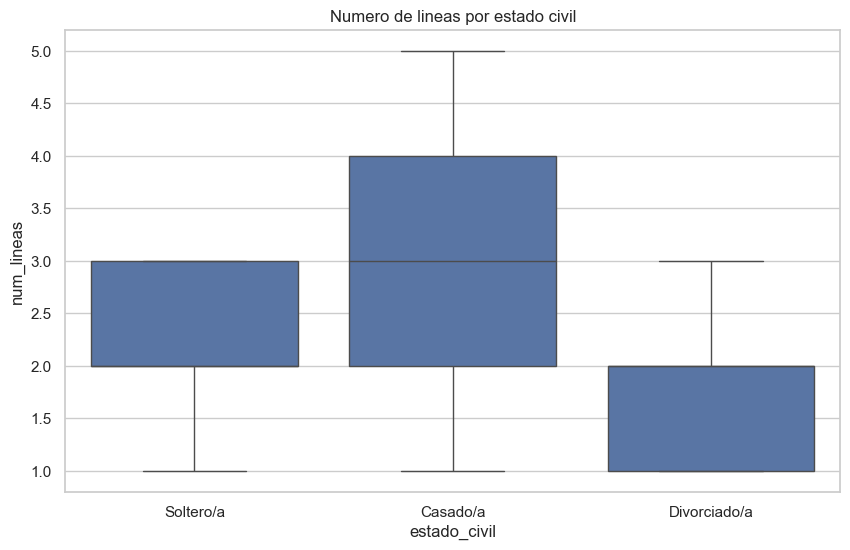

,count,median,mean
estado_civil,,,
Divorciado/a,777,2.00,1.90
Soltero/a,5504,2.00,2.01
Casado/a,3569,3.00,2.86


Estadistico Kruskal-Wallis: 1272.865
P-valor: 0.000000


In [31]:
df_h3 = df_eda.dropna(subset=['estado_civil', 'num_lineas']).copy()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_h3, x='estado_civil', y='num_lineas', order=['Soltero/a', 'Casado/a', 'Divorciado/a'])
plt.title('Numero de lineas por estado civil')
plt.show()

groups_h3 = [
    df_h3.loc[df_h3['estado_civil'] == est, 'num_lineas']
    for est in ['Soltero/a', 'Casado/a', 'Divorciado/a']
]

kw_h3 = stats.kruskal(*groups_h3)
summary_h3 = df_h3.groupby('estado_civil')['num_lineas'].agg(['count', 'median', 'mean']).sort_values('median')

display(summary_h3)
print(f'Estadistico Kruskal-Wallis: {kw_h3.statistic:.3f}')
print(f'P-valor: {kw_h3.pvalue:.6f}')


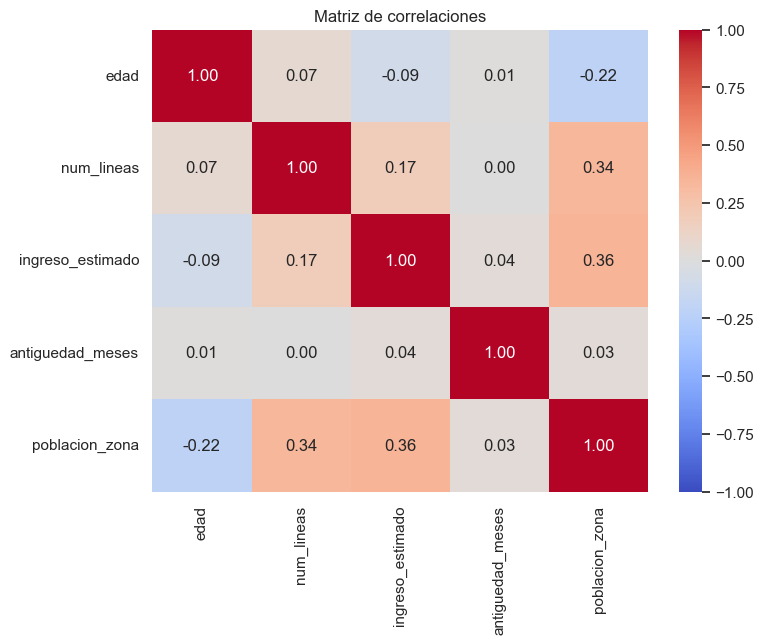

,ingreso_estimado,num_lineas,antiguedad_meses
tipo_zona,,,
rural,"2,370.50",2.00,28.00
suburbana,"2,963.00",2.00,29.00
urbana_premium,"3,832.00",3.00,30.00


In [32]:
corr_cols = ['edad', 'num_lineas', 'ingreso_estimado', 'antiguedad_meses', 'poblacion_zona']
corr = df_eda[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Matriz de correlaciones')
plt.show()

display(
    df_eda.groupby('tipo_zona')[['ingreso_estimado', 'num_lineas', 'antiguedad_meses']]
    .median()
    .round(2)
)


## 7. Lectura de negocio

Aunque este dataset no contiene aun la variable objetivo de churn, si aporta informacion muy valiosa para perfilar clientes y construir features futuras.

Aspectos especialmente relevantes:

- `tipo_plan`, `num_lineas` y `descuento_activo` pueden aproximar valor comercial y estrategia de retencion.
- `antiguedad_meses` suele ser una variable importante en modelos de permanencia o abandono.
- `tipo_zona`, `region` y `poblacion_zona` conectan el cliente con el contexto territorial y, potencialmente, con la calidad de red.
- `tipo_dispositivo` e `ingreso_estimado` pueden capturar diferencias de segmento socioeconomico.

Un punto clave como profesor: ninguna de estas variables explica por si sola el churn. Su valor esta en la combinacion con tablas de facturacion, soporte, encuestas y calidad de senal.


## 8. Conclusiones del EDA

Conclusiones tecnicas:

- El dataset tiene una estructura coherente de cliente, pero presenta incidencias de calidad relevantes.
- Existen nulos en variables numericas importantes y categorias fuera de catalogo.
- Hay duplicados exactos y casos imposibles, como antiguedad negativa.
- Por tanto, cualquier pipeline posterior debe incluir una fase explicita de limpieza y validacion.

Conclusiones analiticas:

- La cartera parece segmentada por plan, dispositivo, zona y nivel de ingreso.
- Las diferencias entre planes y perfiles no son solo comerciales; probablemente tambien tendran implicaciones en churn, ARPU y experiencia de cliente.
- El dataset es util tanto para analisis descriptivo como para feature engineering posterior.

Siguiente paso natural:

Construir un notebook de data cleaning para `clientes.csv` y, despues, unificar esta tabla con las fuentes transaccionales del caso.
